In [2]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
import tsfel
import time
import numpy as np

In [3]:
nSet = 0
fileTS = os.path.join(os.getcwd(), "pdfTimeSeries{:d}.pkl".format(nSet))
pdfTS = pd.read_pickle(fileTS)

In [4]:
pdfTS

,u,y,i,e
0,0.000000,-0.076287,9N6FK96G8,-0.076287
1,0.000000,0.019506,9N6FK96G8,0.019506
2,0.000000,-0.073928,9N6FK96G8,-0.073928
3,0.000000,0.044727,9N6FK96G8,0.044727
4,0.000000,-0.010317,9N6FK96G8,-0.010317
...,...,...,...,...
718,-0.465181,-0.449052,UMTMULQVC,0.016130
719,-0.465181,-0.417802,UMTMULQVC,0.047379
720,-0.465181,-0.510018,UMTMULQVC,-0.044837
721,-0.465181,-0.507332,UMTMULQVC,-0.042151


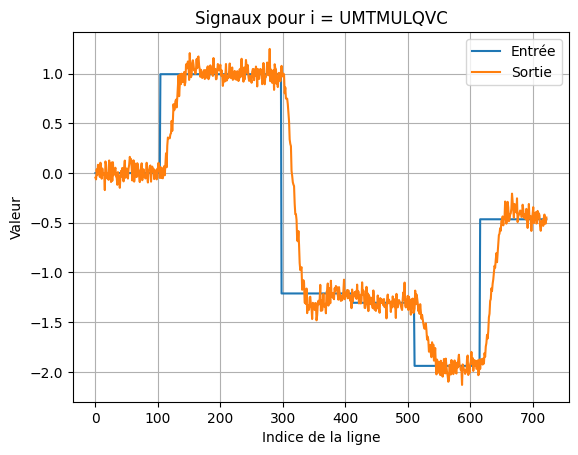

In [5]:
identifiant = "UMTMULQVC"

pdfTS_filtre = pdfTS[pdfTS["i"] == identifiant]

pdfTS_filtre["u"].plot(label="Entrée")
pdfTS_filtre["y"].plot(label="Sortie")


plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [6]:
fileEF = os.path.join(os.getcwd(), "pdfFeatures{:d}.pkl".format(nSet))
pdfEF = pd.read_pickle(fileEF)

In [7]:
pdfEF

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.030425,0.057124,1.0,0.016903,0.799343,2.0,8.0,-0.073928,0.044727,0.1,...,0.004341,0.003173,0.001785,0.00109,0.000761,0.00059,0.000489,0.000423,6.0,9N6FK96G8
1,0.034108,0.071956,2.0,0.018949,0.870813,2.0,8.0,-0.068527,0.031442,0.1,...,0.003611,0.003788,0.003008,0.002341,0.001897,0.001597,0.001382,0.001221,4.0,9N6FK96G8
2,0.042274,0.083902,1.0,0.023486,0.962404,2.0,8.0,-0.105961,0.016858,0.1,...,0.001518,0.000854,0.000852,0.000831,0.000794,0.000749,0.000702,0.000656,4.0,9N6FK96G8
3,0.033578,0.080128,2.0,0.018654,0.551002,2.0,8.0,-0.104259,0.021024,0.1,...,0.007749,0.006425,0.00425,0.003015,0.002334,0.001921,0.001645,0.001445,3.0,9N6FK96G8
4,0.023003,0.049324,1.0,0.012779,1.067663,2.0,8.0,-0.015203,0.035602,0.1,...,0.0012,0.001165,0.000987,0.000811,0.000682,0.00059,0.00052,0.000465,4.0,9N6FK96G8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49311,0.058049,0.090205,1.0,0.032249,0.799835,2.0,8.0,-0.087101,0.032083,0.1,...,0.031444,0.015267,0.019952,0.027048,0.031054,0.032461,0.032345,0.031438,0.0,UMTMULQVC
49312,0.035514,0.066874,1.0,0.01973,0.918799,2.0,8.0,-0.038623,0.032083,0.1,...,0.017774,0.017436,0.023716,0.028415,0.030289,0.030336,0.02944,0.028123,0.0,UMTMULQVC
49313,0.035254,0.063878,1.0,0.019586,0.700099,2.0,8.0,-0.038623,0.070625,0.1,...,0.012935,0.018426,0.027143,0.031986,0.033404,0.032951,0.031636,0.029988,0.0,UMTMULQVC
49314,0.041431,0.080162,1.0,0.023017,1.048823,2.0,8.0,-0.073158,0.060267,0.1,...,0.032227,0.018178,0.02272,0.029591,0.033423,0.034674,0.034409,0.033364,0.0,UMTMULQVC


***DATA PREP***

Step 1,2,3 : Cleaning, scaling and spliting data

In [8]:
import numpy as np
import pandas as pd

# Copie du dataframe de features
df = pdfEF.copy()

# On enlève l'identifiant des features si la colonne existe
X = df.drop(columns=["i"], errors="ignore")

# Conversion en numérique
X = X.apply(pd.to_numeric, errors="coerce")

# Remplacement des valeurs infinies
X = X.replace([np.inf, -np.inf], np.nan)

# Suppression des colonnes complètement vides
X = X.dropna(axis=1, how="all")

# Remplacement des valeurs manquantes par la médiane
X = X.fillna(X.median())

# Suppression des colonnes constantes
X = X.loc[:, X.nunique(dropna=True) > 1]

print("Shape après cleaning :", X.shape)

Shape après cleaning : (49316, 246)


Split

In [9]:
from sklearn.model_selection import train_test_split

# Indices pour retrouver les lignes originales après le split
indices = np.arange(X.shape[0])

X_train, X_test, idx_train, idx_test = train_test_split(
    X,
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

X_train : (39452, 246)
X_test : (9864, 246)


Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling terminé")

Scaling terminé


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.7, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Nombre de features au départ :", X.shape[1])
print("Nombre de composantes PCA gardées :", X_train_pca.shape[1])
print("Variance expliquée :", round(pca.explained_variance_ratio_.sum(), 4))

Nombre de features au départ : 246
Nombre de composantes PCA gardées : 14
Variance expliquée : 0.7042


**Kernel Density Estimation**

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
import time

t0 = time.time()

# Split du train PCA en :
# - une partie pour entraîner la KDE
# - une partie pour définir le seuil de vraisemblance
X_kde_train, X_kde_val = train_test_split(
    X_train_pca,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

# Échantillon pour accélérer la KDE
n_sample = min(3000, len(X_kde_train))

sample_idx = np.random.choice(
    len(X_kde_train),
    size=n_sample,
    replace=False
)

X_kde_sample = X_kde_train[sample_idx]

print("Taille utilisée pour KDE :", X_kde_sample.shape)

# Intervalle borné de recherche du bandwidth
bandwidth_min = 0.1
bandwidth_max = 2.0
nb_tests = 10

bandwidth_values = np.linspace(
    bandwidth_min,
    bandwidth_max,
    nb_tests
)

params = {
    "bandwidth": bandwidth_values
}

# Recherche du meilleur bandwidth
grid = GridSearchCV(
    KernelDensity(kernel="gaussian"),
    params,
    cv=3
)

grid.fit(X_kde_sample)

best_bandwidth = grid.best_params_["bandwidth"]

print("Meilleur bandwidth trouvé :", best_bandwidth)

# KDE final avec le meilleur bandwidth
kde = KernelDensity(
    kernel="gaussian",
    bandwidth=best_bandwidth
)

kde.fit(X_kde_sample)

print("Temps entraînement KDE :", round(time.time() - t0, 2), "secondes")

Taille utilisée pour KDE : (3000, 14)
Meilleur bandwidth trouvé : 1.1555555555555557
Temps entraînement KDE : 2.63 secondes


In [13]:
# Log-vraisemblance sur validation et test
val_log_likelihood = kde.score_samples(X_kde_val)
test_log_likelihood = kde.score_samples(X_test_pca)

# Seuil : les 20% avec la plus faible vraisemblance sont considérés comme points de bord
threshold = np.percentile(val_log_likelihood, 20)

# Détection sur le test
test_is_border = test_log_likelihood < threshold

print("Seuil de log-vraisemblance :", threshold)
print("Nombre de points test :", len(test_is_border))
print("Points sur les bords :", test_is_border.sum())
print("Pourcentage :", round(test_is_border.mean() * 100, 2), "%")

Seuil de log-vraisemblance : -29.646461606512652
Nombre de points test : 9864
Points sur les bords : 1891
Pourcentage : 19.17 %


In [14]:
df_test_result = df.iloc[idx_test].copy()

df_test_result["log_likelihood"] = test_log_likelihood
df_test_result["is_border"] = test_is_border

df_test_result[["log_likelihood", "is_border"]].head(20)

,log_likelihood,is_border
48186,-23.644292,False
38307,-27.753581,False
47752,-22.967736,False
44372,-24.981418,False
147,-28.237845,False
14174,-26.028081,False
28078,-34.752465,True
6095,-24.262665,False
37486,-24.863209,False
33555,-27.260032,False


In [15]:
df_test_result.sort_values("log_likelihood")[["log_likelihood", "is_border"]].head(20)

,log_likelihood,is_border
18237,-103.085224,True
16030,-98.211647,True
41595,-96.260985,True
17894,-92.752791,True
30240,-91.821722,True
39846,-90.856062,True
41593,-89.168294,True
38499,-87.716831,True
39849,-86.935088,True
24389,-83.891935,True


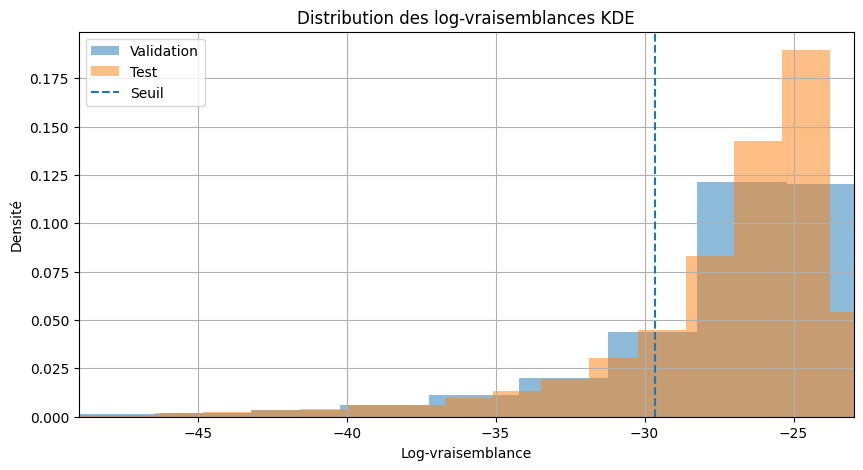

In [16]:
import matplotlib.pyplot as plt

all_scores = np.concatenate([val_log_likelihood, test_log_likelihood])

xmin = np.percentile(all_scores, 1)
xmax = np.percentile(all_scores, 99)

plt.figure(figsize=(10, 5))

plt.hist(
    val_log_likelihood,
    bins=50,
    density=True,
    alpha=0.5,
    label="Validation"
)

plt.hist(
    test_log_likelihood,
    bins=50,
    density=True,
    alpha=0.5,
    label="Test"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Seuil"
)

plt.xlim(xmin, xmax)

plt.xlabel("Log-vraisemblance")
plt.ylabel("Densité")
plt.title("Distribution des log-vraisemblances KDE")
plt.legend()
plt.grid()
plt.show()

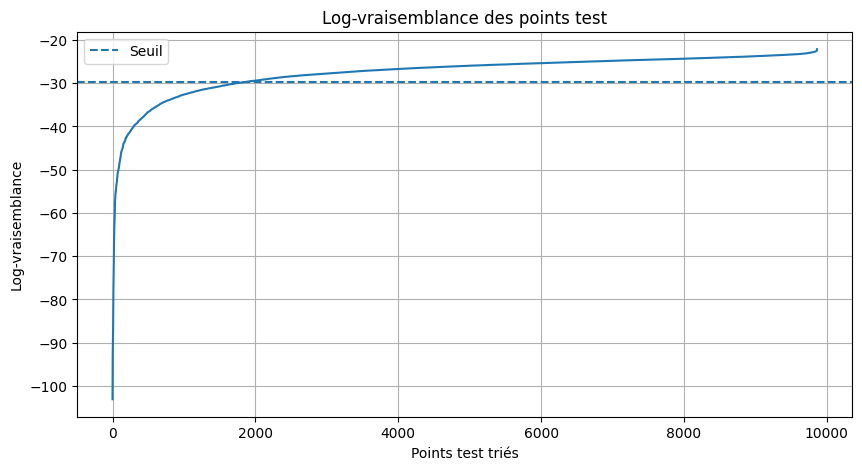

In [17]:
sorted_scores = np.sort(test_log_likelihood)

plt.figure(figsize=(10, 5))

plt.plot(sorted_scores)
plt.axhline(threshold, linestyle="--", label="Seuil")

plt.xlabel("Points test triés")
plt.ylabel("Log-vraisemblance")
plt.title("Log-vraisemblance des points test")
plt.legend()
plt.grid()
plt.show()

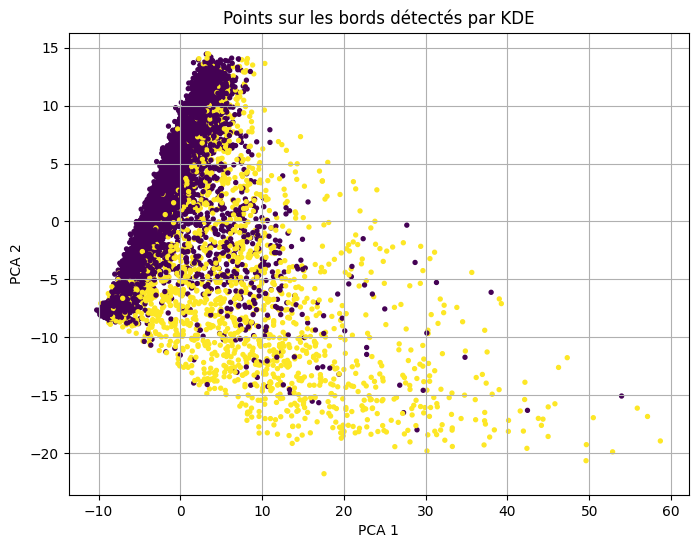

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=test_is_border,
    s=8
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Points sur les bords détectés par KDE")
plt.grid()
plt.show()

---
****Fichier avec défaut 1****
---

In [19]:
nSet = 0
fileTS_def = os.path.join(os.getcwd(), "pdfTimeSeries1.pkl".format(nSet))
pdfTS_def = pd.read_pickle(fileTS_def)

In [20]:
pdfTS_def

,u,y,i,e
0,0.000000,-0.178862,VJG2XDS11,-0.178862
1,0.000000,0.009132,VJG2XDS11,0.009132
2,0.000000,0.058681,VJG2XDS11,0.058681
3,0.000000,0.010686,VJG2XDS11,0.010686
4,0.000000,-0.001032,VJG2XDS11,-0.001032
...,...,...,...,...
1805,0.933992,0.924232,RJ9RSGP8N,-0.009760
1806,0.933992,1.047756,RJ9RSGP8N,0.113764
1807,0.933992,0.923011,RJ9RSGP8N,-0.010981
1808,0.933992,0.878074,RJ9RSGP8N,-0.055918


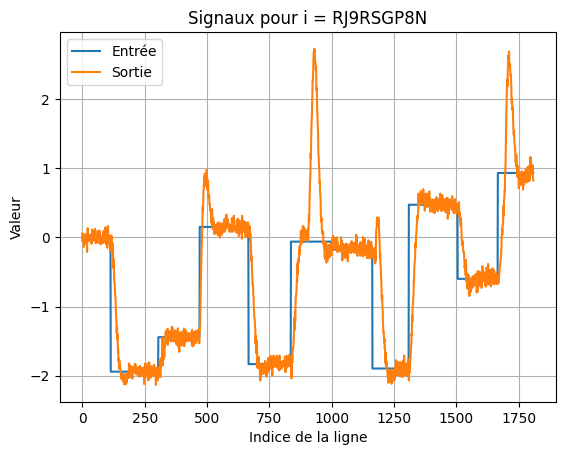

In [21]:
identifiant = "RJ9RSGP8N"

pdfTSdef_filtre = pdfTS_def[pdfTS_def["i"] == identifiant]

pdfTSdef_filtre["u"].plot(label="Entrée")
pdfTSdef_filtre["y"].plot(label="Sortie")

plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [22]:
fileEF_default = os.path.join(os.getcwd(), "pdfFeatures1.pkl".format(nSet))
pdfEF_default = pd.read_pickle(fileEF_default)

In [23]:
pdfEF_default

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.079972,0.070585,1.0,0.044429,0.743867,2.0,8.0,-0.16203,0.058681,0.1,...,0.006549,0.002512,0.000561,0.000079,0.000034,0.000084,0.000139,0.00018,7.0,VJG2XDS11
1,0.113216,0.108242,1.0,0.062898,1.067862,2.0,8.0,-0.16203,0.070568,0.1,...,0.012497,0.004955,0.001334,0.000357,0.000192,0.000225,0.000287,0.000336,5.0,VJG2XDS11
2,0.080514,0.102533,1.0,0.04473,0.673056,2.0,8.0,-0.071974,0.020168,0.1,...,0.00544,0.003927,0.002602,0.001843,0.001432,0.001188,0.001027,0.000911,3.0,VJG2XDS11
3,0.041541,0.086099,1.0,0.023078,0.947138,2.0,8.0,-0.089413,0.004123,0.1,...,0.000665,0.000911,0.000832,0.000722,0.000634,0.000565,0.000509,0.000463,4.0,VJG2XDS11
4,0.032314,0.046819,1.0,0.017952,0.264517,2.0,8.0,-0.089413,0.017185,0.1,...,0.002195,0.002557,0.002071,0.001648,0.001362,0.001164,0.001019,0.000907,6.0,VJG2XDS11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9978,0.043084,0.066947,1.0,0.023935,0.874975,2.0,8.0,-0.070085,0.036081,0.1,...,0.050158,0.070849,0.107633,0.130185,0.1382,0.137748,0.133162,0.12683,0.0,RJ9RSGP8N
9979,0.056206,0.071727,1.0,0.031225,1.017963,2.0,8.0,-0.070085,0.086244,0.1,...,0.062573,0.06251,0.095131,0.120334,0.131557,0.133555,0.130661,0.125468,0.0,RJ9RSGP8N
9980,0.098005,0.111591,1.0,0.054447,1.168855,2.0,8.0,-0.100425,0.089533,0.1,...,0.062877,0.070356,0.103128,0.127363,0.137766,0.139117,0.135697,0.130065,0.0,RJ9RSGP8N
9981,0.067764,0.08189,1.0,0.037647,0.58618,2.0,8.0,-0.01493,0.034071,0.1,...,0.056094,0.081339,0.119263,0.141201,0.148211,0.146773,0.141318,0.134241,0.0,RJ9RSGP8N


In [24]:
# =====================================================
# 1. Préparation du dataframe défaut dataset1
# =====================================================

df_default_original = pdfEF_default.copy()

# On enlève l'identifiant si présent
X_default = df_default_original.drop(columns=["i"], errors="ignore")

# Conversion en numérique
X_default = X_default.apply(pd.to_numeric, errors="coerce")

# Remplacement des valeurs infinies
X_default = X_default.replace([np.inf, -np.inf], np.nan)

# =====================================================
# 2. Alignement avec les colonnes utilisées sur le dataset sain
# =====================================================

for col in X.columns:
    if col not in X_default.columns:
        X_default[col] = np.nan

# Même ordre de colonnes que le dataset sain
X_default = X_default[X.columns]

# Remplacement des NaN avec la médiane du dataset sain
X_default = X_default.fillna(X.median())

# Sécurité finale
X_default = X_default.replace([np.inf, -np.inf], np.nan)
X_default = X_default.fillna(X.median())

print("Shape défaut après préparation :", X_default.shape)

Shape défaut après préparation : (9983, 246)


In [25]:
# =====================================================
# 3. Application du pipeline appris sur les données saines
# =====================================================

X_default_scaled = scaler.transform(X_default)

X_default_pca = pca.transform(X_default_scaled)

default_log_likelihood = kde.score_samples(X_default_pca)

In [26]:
# =====================================================
# 4. Création du dataframe résultat défaut
# =====================================================

df_default_result = df_default_original.copy()

df_default_result["log_likelihood"] = default_log_likelihood
df_default_result["is_border"] = df_default_result["log_likelihood"] < threshold
df_default_result["is_normal"] = df_default_result["log_likelihood"] >= threshold
df_default_result["anomaly_score"] = -df_default_result["log_likelihood"]

df_default_result[["i", "log_likelihood", "is_normal", "is_border", "anomaly_score"]].head()

,i,log_likelihood,is_normal,is_border,anomaly_score
0,VJG2XDS11,-25.474859,True,False,25.474859
1,VJG2XDS11,-30.787005,False,True,30.787005
2,VJG2XDS11,-25.455524,True,False,25.455524
3,VJG2XDS11,-33.760853,False,True,33.760853
4,VJG2XDS11,-27.075345,True,False,27.075345


In [27]:
# Recalcul du statut de chaque fenêtre défaut à partir du seuil KDE
df_default_result["is_border"] = df_default_result["log_likelihood"] < threshold
df_default_result["is_normal"] = df_default_result["log_likelihood"] >= threshold

# Score d'anomalie
df_default_result["anomaly_score"] = -df_default_result["log_likelihood"]

df_default_result[["i", "log_likelihood", "is_normal", "is_border", "anomaly_score"]].head()

,i,log_likelihood,is_normal,is_border,anomaly_score
0,VJG2XDS11,-25.474859,True,False,25.474859
1,VJG2XDS11,-30.787005,False,True,30.787005
2,VJG2XDS11,-25.455524,True,False,25.455524
3,VJG2XDS11,-33.760853,False,True,33.760853
4,VJG2XDS11,-27.075345,True,False,27.075345


In [28]:
# =====================================================
# Agrégation des fenêtres défauts par identifiant
# =====================================================

summary_default = df_default_result.groupby("i").agg(
    nb_windows=("is_border", "count"),
    nb_windows_anormales=("is_border", "sum"),
    pct_windows_anormales=("is_border", "mean"),
    mean_log_likelihood=("log_likelihood", "mean"),
    min_log_likelihood=("log_likelihood", "min"),
    max_anomaly_score=("anomaly_score", "max"),
    mean_anomaly_score=("anomaly_score", "mean")
).reset_index()

# Conversion en pourcentage
summary_default["pct_windows_anormales"] = summary_default["pct_windows_anormales"] * 100

summary_default.head()

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,mean_log_likelihood,min_log_likelihood,max_anomaly_score,mean_anomaly_score
0,2U2HN8U8D,323,107,33.126935,-30.695658,-148.200650,148.200650,30.695658
1,3A2AKKKHI,314,77,24.522293,-41.165161,-1454.894186,1454.894186,41.165161
2,48WK1UQQO,329,106,32.218845,-38.060774,-387.487908,387.487908,38.060774
3,6QXC4QTK2,203,66,32.512315,-31.941401,-129.548443,129.548443,31.941401
4,87UUY7547,242,78,32.231405,-42.004926,-674.415989,674.415989,42.004926


In [29]:
seuil_id = 10

summary_default["id_detected_faulty"] = summary_default["pct_windows_anormales"] >= seuil_id

summary_default[[
    "i",
    "nb_windows",
    "nb_windows_anormales",
    "pct_windows_anormales",
    "id_detected_faulty"
]].head(20)

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,id_detected_faulty
0,2U2HN8U8D,323,107,33.126935,True
1,3A2AKKKHI,314,77,24.522293,True
2,48WK1UQQO,329,106,32.218845,True
3,6QXC4QTK2,203,66,32.512315,True
4,87UUY7547,242,78,32.231405,True
5,8IWYZ3WFE,187,61,32.620321,True
6,9DI4D2S36,162,63,38.888889,True
7,AQ86JGMKW,232,86,37.068966,True
8,AZTVA5ZWX,259,92,35.521236,True
9,D3R3JJGIL,314,97,30.891720,True


In [30]:
print("Nombre total d'identifiants défauts :", len(summary_default))
print("Identifiants détectés faulty :", summary_default["id_detected_faulty"].sum())
print("Pourcentage détecté :", round(summary_default["id_detected_faulty"].mean() * 100, 2), "%")

Nombre total d'identifiants défauts : 40
Identifiants détectés faulty : 40
Pourcentage détecté : 100.0 %


In [31]:
summary_default.sort_values(
    by="pct_windows_anormales",
    ascending=False
).head(5)

,i,nb_windows,nb_windows_anormales,pct_windows_anormales,mean_log_likelihood,min_log_likelihood,max_anomaly_score,mean_anomaly_score,id_detected_faulty
17,KIQ82T2TF,142,58,40.845070,-33.761475,-135.301079,135.301079,33.761475,True
6,9DI4D2S36,162,63,38.888889,-35.575459,-179.703745,179.703745,35.575459,True
31,V25U5JPDP,204,79,38.725490,-45.075377,-418.870995,418.870995,45.075377,True
24,QRJ024QY0,177,68,38.418079,-40.094440,-463.265083,463.265083,40.094440,True
15,GAJOFQ4RL,205,78,38.048780,-31.573202,-112.471368,112.471368,31.573202,True


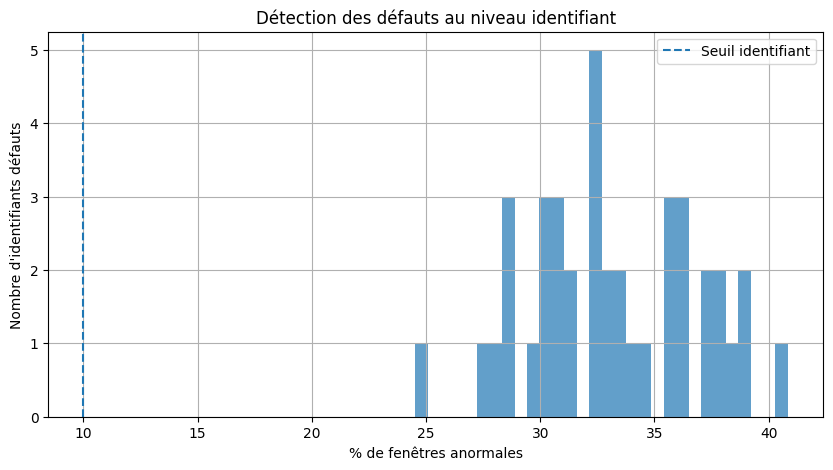

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    summary_default["pct_windows_anormales"],
    bins=30,
    alpha=0.7
)

plt.axvline(
    seuil_id,
    linestyle="--",
    label="Seuil identifiant"
)

plt.xlabel("% de fenêtres anormales")
plt.ylabel("Nombre d'identifiants défauts")
plt.title("Détection des défauts au niveau identifiant")
plt.legend()
plt.grid()
plt.show()

---
**Jour 2**
---

**Dataset 2**

In [33]:
fileTS2 = os.path.join(os.getcwd(), "pdfTimeSeries2.pkl".format(nSet))
pdfTS2 = pd.read_pickle(fileTS2)

In [34]:
pdfTS2

,u,y,i,e
0,0.000000,-0.056065,IQVYTIVZI,-0.056065
1,0.000000,0.004750,IQVYTIVZI,0.004750
2,0.000000,-0.088224,IQVYTIVZI,-0.088224
3,0.000000,0.103965,IQVYTIVZI,0.103965
4,0.000000,-0.105212,IQVYTIVZI,-0.105212
...,...,...,...,...
1129,-1.499424,-1.521239,9DLVY2MTM,-0.021815
1130,-1.499424,-1.464248,9DLVY2MTM,0.035176
1131,-1.499424,-1.528087,9DLVY2MTM,-0.028663
1132,-1.499424,-1.509753,9DLVY2MTM,-0.010329


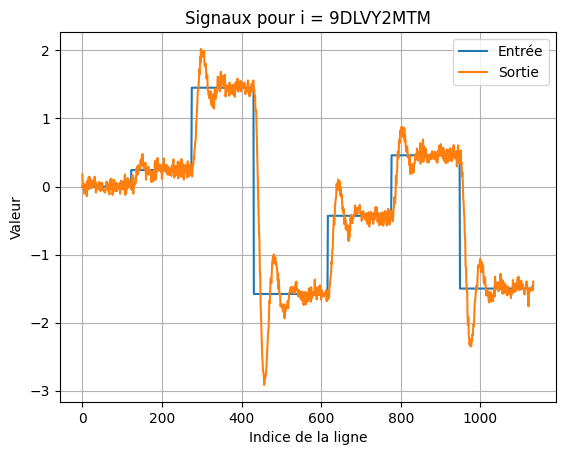

In [35]:
identifiant = "9DLVY2MTM"

pdfTS2_filtre = pdfTS2[pdfTS2["i"] == identifiant]

pdfTS2_filtre["u"].plot(label="Entrée")
pdfTS2_filtre["y"].plot(label="Sortie")


plt.xlabel("Indice de la ligne")
plt.ylabel("Valeur")
plt.title(f"Signaux pour i = {identifiant}")
plt.grid()
plt.legend()
plt.show()

In [36]:
fileEF2 = os.path.join(os.getcwd(), "pdfFeatures2.pkl".format(nSet))
pdfEF2 = pd.read_pickle(fileEF2)

In [37]:
pdfEF2

,e_Absolute energy,e_Area under the curve,e_Autocorrelation,e_Average power,e_Centroid,e_ECDF Percentile Count_0,e_ECDF Percentile Count_1,e_ECDF Percentile_0,e_ECDF Percentile_1,e_ECDF_0,...,y_Wavelet variance_1,y_Wavelet variance_2,y_Wavelet variance_3,y_Wavelet variance_4,y_Wavelet variance_5,y_Wavelet variance_6,y_Wavelet variance_7,y_Wavelet variance_8,y_Zero crossing rate,i
0,0.059216,0.044443,1.0,0.032898,0.804866,2.0,8.0,-0.088224,0.064545,0.1,...,0.002374,0.002111,0.001411,0.001006,0.000791,0.000666,0.000583,0.000523,7.0,IQVYTIVZI
1,0.044947,0.057335,1.0,0.02497,0.595348,2.0,8.0,-0.068292,0.039978,0.1,...,0.00388,0.002158,0.001157,0.000822,0.000707,0.000652,0.000613,0.000579,5.0,IQVYTIVZI
2,0.043168,0.077023,1.0,0.023982,0.854625,2.0,8.0,-0.068292,0.039978,0.1,...,0.002692,0.001613,0.001324,0.00114,0.001017,0.000925,0.000849,0.000783,3.0,IQVYTIVZI
3,0.0533,0.094651,1.0,0.029611,0.786584,2.0,8.0,-0.098149,0.055082,0.1,...,0.010799,0.00719,0.00392,0.00242,0.001731,0.001374,0.001161,0.001017,3.0,IQVYTIVZI
4,0.067602,0.08591,1.0,0.037556,0.725336,2.0,8.0,-0.113625,0.055082,0.1,...,0.002384,0.002523,0.002059,0.001659,0.001402,0.001226,0.001096,0.000994,5.0,IQVYTIVZI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37364,0.029434,0.079779,1.0,0.016352,0.681912,2.0,8.0,0.010078,0.060526,0.1,...,0.126341,0.151998,0.23587,0.294779,0.319444,0.322508,0.314392,0.301166,0.0,9DLVY2MTM
37365,0.019913,0.056061,2.0,0.011063,0.7887,2.0,8.0,-0.068776,0.0105,0.1,...,0.121303,0.184962,0.284286,0.343689,0.364472,0.363008,0.350744,0.333949,0.0,9DLVY2MTM
37366,0.026585,0.059124,2.0,0.01477,0.736369,2.0,8.0,-0.068776,0.03031,0.1,...,0.142319,0.152249,0.233226,0.294619,0.321876,0.32668,0.319572,0.306864,0.0,9DLVY2MTM
37367,0.109663,0.140839,2.0,0.060924,1.078961,2.0,8.0,-0.128093,0.03031,0.1,...,0.129391,0.218209,0.327399,0.387338,0.405553,0.400808,0.385341,0.365649,0.0,9DLVY2MTM


**Amélioration jour 4 sur le dataset 3**

In [38]:
nSet = 0
fileTS3 = os.path.join(os.getcwd(), "pdfTimeSeries3.pkl".format(nSet))
pdfTS3 = pd.read_pickle(fileTS3)

In [39]:
fileEF3 = os.path.join(os.getcwd(), "pdfFeatures3.pkl".format(nSet))
pdfEF3 = pd.read_pickle(fileEF3)

In [40]:
# ============================================================
# CLASSIFICATION DATASET3 AVEC KDE + K-MEANS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

---
Paramètres Dataset3
---

In [129]:
ID_COL = "i"

# KDE en faible dimension
N_PCA = 3

N_D2_DEFECTS = 2
N_D3_NEW_DEFECTS = 3

# Seuils plus permissifs pour reconnaître normal et fault_1
KDE_THRESHOLD_Q_NORMAL = 0.01
KDE_THRESHOLD_Q_FAULT1 = 0.01

# Pour les défauts appris du dataset2, on reste plus strict
KDE_THRESHOLD_Q_D2 = 0.20

# Marges : négatif = plus permissif
MARGIN_NORMAL = -0.50
MARGIN_FAULT1 = -0.50
MARGIN_D2_DEFECT = 0.15

# Seuils d'acceptation observés manuellement
ACCEPT_SCORE_BY_LABEL = {
    "normal": 1.6,
    "fault_1": 1.85,
    
    # Pour les défauts appris du dataset2, on garde un seuil neutre pour l'instant
    "d2_defect_0": 1,
    "d2_defect_1": -1
}

# Grille de bandwidth KDE
BANDWIDTH_GRID = np.logspace(-1.5, 1.2, 25)

# Facteur pour lisser un peu plus les KDE normal/fault_1
BW_FACTOR_NORMAL = 1.8
BW_FACTOR_FAULT1 = 1.8
BW_FACTOR_D2 = 1.2

RANDOM_STATE = 42

In [130]:
# ============================================================
# 2. DÉCLARATION DES DATASETS
# ============================================================

df_normal = pdfEF.copy()          # dataset0 : normal
df_fault1 = pdfEF_default.copy()   # dataset1 : défaut 1
df_d2 = pdfEF2.copy()             # dataset2 : mélange avec nouveaux défauts
df_d3 = pdfEF3.copy()             # dataset3 : à classifier

print("Dataset0 normal :", df_normal.shape)
print("Dataset1 défaut 1 :", df_fault1.shape)
print("Dataset2 :", df_d2.shape)
print("Dataset3 :", df_d3.shape)

Dataset0 normal : (49316, 275)
Dataset1 défaut 1 : (9983, 275)
Dataset2 : (37369, 275)
Dataset3 : (39533, 275)


In [131]:
# ============================================================
# 3. FEATURES COMMUNES
# ============================================================

cols_to_exclude = [
    ID_COL,
    "type", "label", "target", "classe", "class",
    "final_label", "cluster", "label_known"
]

feature_cols = [
    col for col in df_d3.columns
    if col not in cols_to_exclude
    and col in df_normal.columns
    and col in df_fault1.columns
    and col in df_d2.columns
]

print("Nombre de features communes :", len(feature_cols))

if len(feature_cols) == 0:
    raise ValueError("Aucune feature commune trouvée. Vérifie les noms de colonnes.")

Nombre de features communes : 274


In [132]:
# ============================================================
# 4. AGRÉGATION DES FENÊTRES : 1 LIGNE PAR IDENTIFIANT
# ============================================================

def prepare_agg(df, feature_cols, id_col):
    temp = df[[id_col] + feature_cols].copy()
    
    for col in feature_cols:
        temp[col] = (
            temp[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
        )
        temp[col] = pd.to_numeric(temp[col], errors="coerce")
    
    temp = temp.replace([np.inf, -np.inf], np.nan)
    
    df_agg = temp.groupby(id_col)[feature_cols].mean().reset_index()
    
    return df_agg


normal_agg = prepare_agg(df_normal, feature_cols, ID_COL)
fault1_agg = prepare_agg(df_fault1, feature_cols, ID_COL)
d2_agg = prepare_agg(df_d2, feature_cols, ID_COL)
d3_agg = prepare_agg(df_d3, feature_cols, ID_COL)

print("Normal agrégé :", normal_agg.shape)
print("Fault 1 agrégé :", fault1_agg.shape)
print("Dataset2 agrégé :", d2_agg.shape)
print("Dataset3 agrégé :", d3_agg.shape)

print("Identifiants dataset3 :", d3_agg[ID_COL].nunique())

Normal agrégé : (200, 275)
Fault 1 agrégé : (40, 275)
Dataset2 agrégé : (150, 275)
Dataset3 agrégé : (160, 275)
Identifiants dataset3 : 160


In [133]:
# ============================================================
# 5. PRÉTRAITEMENT COMMUN : IMPUTER + SCALER + PCA
# La PCA est apprise sur dataset0 + dataset1 + dataset2.
# Dataset3 est seulement transformé.
# ============================================================

X_fit = pd.concat(
    [
        normal_agg[feature_cols],
        fault1_agg[feature_cols],
        d2_agg[feature_cols]
    ],
    ignore_index=True
)

X_normal = normal_agg[feature_cols].copy()
X_fault1 = fault1_agg[feature_cols].copy()
X_d2 = d2_agg[feature_cols].copy()
X_d3 = d3_agg[feature_cols].copy()

# Remplacer infinis par NaN
X_fit = X_fit.replace([np.inf, -np.inf], np.nan)
X_normal = X_normal.replace([np.inf, -np.inf], np.nan)
X_fault1 = X_fault1.replace([np.inf, -np.inf], np.nan)
X_d2 = X_d2.replace([np.inf, -np.inf], np.nan)
X_d3 = X_d3.replace([np.inf, -np.inf], np.nan)

# Supprimer colonnes entièrement vides dans le fit
cols_all_nan = X_fit.columns[X_fit.isna().all()].tolist()

if len(cols_all_nan) > 0:
    print("Colonnes supprimées car entièrement NaN :", cols_all_nan)
    X_fit = X_fit.drop(columns=cols_all_nan)
    X_normal = X_normal.drop(columns=cols_all_nan)
    X_fault1 = X_fault1.drop(columns=cols_all_nan)
    X_d2 = X_d2.drop(columns=cols_all_nan)
    X_d3 = X_d3.drop(columns=cols_all_nan)

# Imputation
imputer = SimpleImputer(strategy="median")

X_fit_imp = imputer.fit_transform(X_fit)
X_normal_imp = imputer.transform(X_normal)
X_fault1_imp = imputer.transform(X_fault1)
X_d2_imp = imputer.transform(X_d2)
X_d3_imp = imputer.transform(X_d3)

cols_after_nan = X_fit.columns

X_fit_imp = pd.DataFrame(X_fit_imp, columns=cols_after_nan)
X_normal_imp = pd.DataFrame(X_normal_imp, columns=cols_after_nan)
X_fault1_imp = pd.DataFrame(X_fault1_imp, columns=cols_after_nan)
X_d2_imp = pd.DataFrame(X_d2_imp, columns=cols_after_nan)
X_d3_imp = pd.DataFrame(X_d3_imp, columns=cols_after_nan)

# Suppression colonnes constantes
selector = VarianceThreshold(threshold=0)

X_fit_var = selector.fit_transform(X_fit_imp)
X_normal_var = selector.transform(X_normal_imp)
X_fault1_var = selector.transform(X_fault1_imp)
X_d2_var = selector.transform(X_d2_imp)
X_d3_var = selector.transform(X_d3_imp)

selected_cols = cols_after_nan[selector.get_support()]

X_fit_var = pd.DataFrame(X_fit_var, columns=selected_cols)
X_normal_var = pd.DataFrame(X_normal_var, columns=selected_cols)
X_fault1_var = pd.DataFrame(X_fault1_var, columns=selected_cols)
X_d2_var = pd.DataFrame(X_d2_var, columns=selected_cols)
X_d3_var = pd.DataFrame(X_d3_var, columns=selected_cols)

print("Features après nettoyage :", X_fit_var.shape[1])

# Limitation des valeurs extrêmes selon le fit
lower = X_fit_var.quantile(0.01)
upper = X_fit_var.quantile(0.99)

X_fit_clip = X_fit_var.clip(lower=lower, upper=upper, axis=1)
X_normal_clip = X_normal_var.clip(lower=lower, upper=upper, axis=1)
X_fault1_clip = X_fault1_var.clip(lower=lower, upper=upper, axis=1)
X_d2_clip = X_d2_var.clip(lower=lower, upper=upper, axis=1)
X_d3_clip = X_d3_var.clip(lower=lower, upper=upper, axis=1)

# Scaling robuste
scaler = RobustScaler()

X_fit_scaled = scaler.fit_transform(X_fit_clip)
X_normal_scaled = scaler.transform(X_normal_clip)
X_fault1_scaled = scaler.transform(X_fault1_clip)
X_d2_scaled = scaler.transform(X_d2_clip)
X_d3_scaled = scaler.transform(X_d3_clip)

X_fit_scaled = np.nan_to_num(X_fit_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_normal_scaled = np.nan_to_num(X_normal_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_fault1_scaled = np.nan_to_num(X_fault1_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_d2_scaled = np.nan_to_num(X_d2_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_d3_scaled = np.nan_to_num(X_d3_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# PCA commune
n_components = min(N_PCA, X_fit_scaled.shape[1], X_fit_scaled.shape[0] - 1)

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)

X_fit_red = pca.fit_transform(X_fit_scaled)
X_normal_red = pca.transform(X_normal_scaled)
X_fault1_red = pca.transform(X_fault1_scaled)
X_d2_red = pca.transform(X_d2_scaled)
X_d3_red = pca.transform(X_d3_scaled)

print("Nombre de composantes PCA :", n_components)
print("Variance expliquée totale :", round(pca.explained_variance_ratio_.sum(), 4))

Features après nettoyage : 262
Nombre de composantes PCA : 3
Variance expliquée totale : 0.6564


c:\Users\louay\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1904: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


In [134]:
# ============================================================
# 6. FONCTIONS KDE
# ============================================================

def fit_kde_model(X_class, label, threshold_q, bandwidth_factor=1.0):
    """
    Entraîne une KDE sur une classe et calcule un seuil de densité.
    Si log_density >= threshold, le point est considéré comme compatible.
    """
    
    X_class = np.asarray(X_class)
    
    if len(X_class) < 3:
        raise ValueError(f"Pas assez de points pour entraîner KDE sur {label}")
    
    cv = min(5, len(X_class))
    
    grid = GridSearchCV(
        KernelDensity(kernel="gaussian"),
        {"bandwidth": BANDWIDTH_GRID},
        cv=cv
    )
    
    grid.fit(X_class)
    
    best_bw = grid.best_params_["bandwidth"]
    final_bw = best_bw * bandwidth_factor
    
    kde = KernelDensity(
        kernel="gaussian",
        bandwidth=final_bw
    )
    
    kde.fit(X_class)
    
    log_density_train = kde.score_samples(X_class)
    threshold = np.quantile(log_density_train, threshold_q)
    
    print(label)
    print("  nb points :", len(X_class))
    print("  bandwidth CV :", round(best_bw, 4))
    print("  bandwidth final :", round(final_bw, 4))
    print("  seuil KDE :", round(threshold, 4))
    
    return {
        "label": label,
        "kde": kde,
        "threshold": threshold,
        "threshold_q": threshold_q,
        "bandwidth": final_bw
    }


def classify_with_kde(X, ids, models, margins=None, accept_score_by_label=None):
    """
    Classe les points avec plusieurs KDE.
    
    Un point est accepté dans une classe si :
    - cette classe est celle qui a le meilleur score KDE
    - son score dépasse le seuil spécifique de cette classe
    
    Exemple :
    normal accepté si score >= 0.70
    fault_1 accepté si score >= 1.65
    """
    
    if margins is None:
        margins = {}
    
    if accept_score_by_label is None:
        accept_score_by_label = {}
    
    df_pred = pd.DataFrame()
    df_pred[ID_COL] = ids
    
    score_cols = []
    
    for label, model in models.items():
        log_density = model["kde"].score_samples(X)
        margin = margins.get(label, 0.0)
        
        score = log_density - model["threshold"] - margin
        
        df_pred[f"log_density_{label}"] = log_density
        df_pred[f"kde_score_{label}"] = score
        
        score_cols.append(f"kde_score_{label}")
    
    # Meilleure classe selon le score KDE
    df_pred["best_score_col"] = df_pred[score_cols].idxmax(axis=1)
    df_pred["best_label"] = df_pred["best_score_col"].str.replace("kde_score_", "", regex=False)
    df_pred["best_score"] = df_pred[score_cols].max(axis=1)
    
    # Seuil associé à la meilleure classe
    df_pred["accept_threshold"] = df_pred["best_label"].map(accept_score_by_label).fillna(0.0)
    
    # Par défaut : unknown
    df_pred["label_known"] = "unknown"
    
    # Acceptation seulement si le score dépasse le seuil de la classe prédite
    mask_accept = df_pred["best_score"] >= df_pred["accept_threshold"]
    
    df_pred.loc[mask_accept, "label_known"] = df_pred.loc[mask_accept, "best_label"]
    
    return df_pred

In [135]:
models_base = {}

models_base["normal"] = fit_kde_model(
    X_normal_red,
    label="normal",
    threshold_q=KDE_THRESHOLD_Q_NORMAL,
    bandwidth_factor=BW_FACTOR_NORMAL
)

models_base["fault_1"] = fit_kde_model(
    X_fault1_red,
    label="fault_1",
    threshold_q=KDE_THRESHOLD_Q_FAULT1,
    bandwidth_factor=BW_FACTOR_FAULT1
)

margins_base = {
    "normal": MARGIN_NORMAL,
    "fault_1": MARGIN_FAULT1
}

normal
  nb points : 200
  bandwidth CV : 1.1885
  bandwidth final : 2.1393
  seuil KDE : -9.544
fault_1
  nb points : 40
  bandwidth CV : 2.5852
  bandwidth final : 4.6534
  seuil KDE : -10.1214


In [136]:
# ============================================================
# 8. TRAITEMENT DU DATASET2
# Objectif : reconnaître normal / fault_1, puis découvrir 2 défauts
# ============================================================

df_d2_pred = classify_with_kde(
    X_d2_red,
    ids=d2_agg[ID_COL].values,
    models=models_base,
    margins=margins_base,
    accept_score_by_label=ACCEPT_SCORE_BY_LABEL
)

print("Dataset2 - résultat KDE normal/fault_1 :")
print(df_d2_pred["label_known"].value_counts())

# Points non reconnus = défauts inconnus du dataset2
idx_d2_unknown = df_d2_pred[df_d2_pred["label_known"] == "unknown"].index
X_d2_unknown = X_d2_red[idx_d2_unknown]

print("Dataset2 - points inconnus à clusteriser :", len(X_d2_unknown))

if len(X_d2_unknown) <= N_D2_DEFECTS:
    raise ValueError("Pas assez de points unknown dans dataset2 pour apprendre les défauts.")

Dataset2 - résultat KDE normal/fault_1 :
label_known
normal     86
unknown    56
fault_1     8
Name: count, dtype: int64
Dataset2 - points inconnus à clusteriser : 56


In [137]:
# ============================================================
# 9. K-MEANS SUR LES UNKNOWN DU DATASET2
# ============================================================

kmeans_d2 = KMeans(
    n_clusters=N_D2_DEFECTS,
    random_state=RANDOM_STATE,
    n_init=50
)

d2_unknown_clusters = kmeans_d2.fit_predict(X_d2_unknown)

df_d2_pred["final_label"] = df_d2_pred["label_known"]

for cluster_id in range(N_D2_DEFECTS):
    local_idx = idx_d2_unknown[d2_unknown_clusters == cluster_id]
    df_d2_pred.loc[local_idx, "final_label"] = f"d2_defect_{cluster_id}"

print("Dataset2 - labels finaux :")
print(df_d2_pred["final_label"].value_counts())

Dataset2 - labels finaux :
final_label
normal         86
d2_defect_0    32
d2_defect_1    24
fault_1         8
Name: count, dtype: int64


In [138]:
print("Dataset2 - résultat KDE normal/fault_1 :")
print(df_d2_pred["label_known"].value_counts())

print("\nSeuils utilisés :")
print(df_d2_pred[["best_label", "best_score", "accept_threshold", "label_known"]].head(20))

print("\nNombre de points acceptés par seuil manuel :")
print("normal :", (df_d2_pred["kde_score_normal"] >= ACCEPT_SCORE_BY_LABEL["normal"]).sum())
print("fault_1 :", (df_d2_pred["kde_score_fault_1"] >= ACCEPT_SCORE_BY_LABEL["fault_1"]).sum())

Dataset2 - résultat KDE normal/fault_1 :
label_known
normal     86
unknown    56
fault_1     8
Name: count, dtype: int64

Seuils utilisés :
   best_label  best_score  accept_threshold label_known
0      normal    2.368318              1.60      normal
1      normal    2.832444              1.60      normal
2      normal    2.939606              1.60      normal
3     fault_1   -5.518602              1.85     unknown
4      normal    2.296627              1.60      normal
5      normal    2.255624              1.60      normal
6      normal    1.878575              1.60      normal
7      normal    2.743710              1.60      normal
8      normal    2.116238              1.60      normal
9      normal    2.848782              1.60      normal
10     normal    1.317656              1.60     unknown
11     normal    1.788610              1.60      normal
12     normal    2.207771              1.60      normal
13     normal    2.695991              1.60      normal
14    fault_1   -4.8

In [139]:
print("\nPoints dataset2 les plus incertains :")

df_debug_d2 = df_d2_pred[
    [
        ID_COL,
        "kde_score_normal",
        "kde_score_fault_1",
        "best_label",
        "best_score",
        "label_known"
    ]
].copy()

# Les points proches de 0 sont les plus ambigus :
# score légèrement positif = accepté de justesse
# score légèrement négatif = rejeté de justesse
df_debug_d2["abs_best_score"] = df_debug_d2["best_score"].abs()

print(
    df_debug_d2
    .sort_values("abs_best_score")
    .head(3)
)


Points dataset2 les plus incertains :
             i  kde_score_normal  kde_score_fault_1 best_label  best_score  \
147  ZI93DSRKV         -0.037700          -3.662223     normal   -0.037700   
101  N30VVGTA0          0.287808          -3.918895     normal    0.287808   
131  W11XA8KQ9          0.598273           0.697889    fault_1    0.697889   

    label_known  abs_best_score  
147     unknown        0.037700  
101     unknown        0.287808  
131     unknown        0.697889  


In [140]:
# =========================
# Table des identifiants les plus proches du défaut 1
# =========================

df_fault1_scores = df_d2_pred[
    [
        ID_COL,
        "kde_score_fault_1",
        "kde_score_normal",
        "best_label",
        "best_score",
        "label_known"
    ]
].copy()

# Tri du meilleur score fault_1 au moins bon
df_fault1_scores = df_fault1_scores.sort_values(
    by="kde_score_fault_1",
    ascending=False
)

# Afficher les 30 meilleurs candidats défaut 1
df_fault1_scores.head(5)

,i,kde_score_fault_1,kde_score_normal,best_label,best_score,label_known
92,LGEGCYMBV,2.230337,-1.809067,fault_1,2.230337,fault_1
86,JV9TP1C0Z,2.222174,-1.791321,fault_1,2.222174,fault_1
73,GPJ515P0Y,2.206067,-3.423529,fault_1,2.206067,fault_1
39,98LY7JJGA,2.145874,-0.674115,fault_1,2.145874,fault_1
57,DAX1FW6U4,2.069020,-2.814321,fault_1,2.069020,fault_1


In [141]:
print("\nIdentifiants dataset2 classés unknown :")

print(
    df_d2_pred[df_d2_pred["label_known"] == "unknown"][
        [
            ID_COL,
            "kde_score_normal",
            "kde_score_fault_1",
            "best_label",
            "best_score",
            "label_known"
        ]
    ].head(5)
)


Identifiants dataset2 classés unknown :
            i  kde_score_normal  kde_score_fault_1 best_label  best_score  \
3   1DACI9FCQ        -11.791825          -5.518602    fault_1   -5.518602   
10  35X6YWYM3          1.317656          -5.920270     normal    1.317656   
14  3JOJRSXPO         -7.023825          -4.827847    fault_1   -4.827847   
17  4398XY0AP          0.121221           1.014070    fault_1    1.014070   
20  4U2ZB99XF          0.719970           0.085975     normal    0.719970   

   label_known  
3      unknown  
10     unknown  
14     unknown  
17     unknown  
20     unknown  


In [142]:
# ============================================================
# 10. ENTRAÎNEMENT KDE SUR LES DÉFAUTS APPRIS DU DATASET2
# ============================================================

models_d2_defects = {}

for cluster_id in range(N_D2_DEFECTS):
    label = f"d2_defect_{cluster_id}"
    
    idx_label = df_d2_pred[df_d2_pred["final_label"] == label].index
    X_label = X_d2_red[idx_label]
    
    models_d2_defects[label] = fit_kde_model(
        X_label,
        label=label,
        threshold_q=KDE_THRESHOLD_Q_D2,
        bandwidth_factor=BW_FACTOR_D2
    )

models_all = {}
models_all.update(models_base)
models_all.update(models_d2_defects)

margins_all = {
    "normal": MARGIN_NORMAL,
    "fault_1": MARGIN_FAULT1,
    "d2_defect_0": MARGIN_D2_DEFECT,
    "d2_defect_1": MARGIN_D2_DEFECT
}

d2_defect_0
  nb points : 32
  bandwidth CV : 3.3497
  bandwidth final : 4.0196
  seuil KDE : -9.3981
d2_defect_1
  nb points : 24
  bandwidth CV : 3.3497
  bandwidth final : 4.0196
  seuil KDE : -9.3481


In [143]:
# ============================================================
# 11. CLASSIFICATION DU DATASET3 AVEC KDE
# normal / fault_1 / d2_defect_0 / d2_defect_1 / unknown
# ============================================================

df_d3_pred = classify_with_kde(
    X_d3_red,
    ids=d3_agg[ID_COL].values,
    models=models_all,
    margins=margins_all,
    accept_score_by_label=ACCEPT_SCORE_BY_LABEL
)

print("Dataset3 - résultat KDE avant K-Means :")
print(df_d3_pred["label_known"].value_counts())

print("\nTop labels KDE :")
print(df_d3_pred[["best_label", "best_score"]].head())

Dataset3 - résultat KDE avant K-Means :
label_known
normal         76
unknown        70
fault_1         8
d2_defect_1     6
Name: count, dtype: int64

Top labels KDE :
  best_label  best_score
0    fault_1    0.734834
1    fault_1    1.694725
2     normal    2.851197
3    fault_1    2.081293
4     normal    1.410830


In [144]:
# ============================================================
# 12. K-MEANS SUR LES UNKNOWN DU DATASET3
# Objectif : découvrir 3 nouveaux défauts
# ============================================================

df_d3_pred["final_label"] = df_d3_pred["label_known"]

idx_d3_unknown = df_d3_pred[df_d3_pred["final_label"] == "unknown"].index
X_d3_unknown = X_d3_red[idx_d3_unknown]

print("Dataset3 - points unknown à clusteriser :", len(X_d3_unknown))

if len(X_d3_unknown) > N_D3_NEW_DEFECTS:
    
    kmeans_d3 = KMeans(
        n_clusters=N_D3_NEW_DEFECTS,
        random_state=RANDOM_STATE,
        n_init=50
    )
    
    d3_unknown_clusters = kmeans_d3.fit_predict(X_d3_unknown)
    
    for cluster_id in range(N_D3_NEW_DEFECTS):
        local_idx = idx_d3_unknown[d3_unknown_clusters == cluster_id]
        df_d3_pred.loc[local_idx, "final_label"] = f"new_defect_{cluster_id + 1}"
    
    if len(set(d3_unknown_clusters)) > 1:
        sil = silhouette_score(X_d3_unknown, d3_unknown_clusters)
        print("Silhouette K-Means dataset3 unknown :", round(sil, 4))

else:
    print("Pas assez de points unknown pour faire K-Means.")

Dataset3 - points unknown à clusteriser : 70
Silhouette K-Means dataset3 unknown : 0.359


In [145]:
# ============================================================
# 13. RÉSUMÉ FINAL DATASET3
# ============================================================

summary_d3 = df_d3_pred["final_label"].value_counts().reset_index()
summary_d3.columns = ["classe_predite", "nombre_identifiants"]

print(summary_d3)
print("\nTotal identifiants classifiés :", summary_d3["nombre_identifiants"].sum())

  classe_predite  nombre_identifiants
0         normal                   76
1   new_defect_3                   25
2   new_defect_1                   23
3   new_defect_2                   22
4        fault_1                    8
5    d2_defect_1                    6

Total identifiants classifiés : 160


In [146]:
# =========================
# Table des identifiants classés d2_defect_0 ou d2_defect_1
# =========================

cols_to_show = [
    ID_COL,
    "final_label",
    "label_known",
    "best_label",
    "best_score",
    "kde_score_normal",
    "kde_score_fault_1",
    "kde_score_d2_defect_0",
    "kde_score_d2_defect_1"
]

df_d2_candidates_d3 = df_d3_pred[
    df_d3_pred["final_label"].isin(["d2_defect_0", "d2_defect_1"])
][cols_to_show].copy()

# On ajoute le meilleur score entre les deux défauts dataset2
df_d2_candidates_d3["best_d2_score"] = df_d2_candidates_d3[
    ["kde_score_d2_defect_0", "kde_score_d2_defect_1"]
].max(axis=1)

# On trie du candidat le plus fort au moins fort
df_d2_candidates_d3 = df_d2_candidates_d3.sort_values(
    by="best_d2_score",
    ascending=False
).reset_index(drop=True)

df_d2_candidates_d3

,i,final_label,label_known,best_label,best_score,kde_score_normal,kde_score_fault_1,kde_score_d2_defect_0,kde_score_d2_defect_1,best_d2_score
0,TNXJMCPHU,d2_defect_1,d2_defect_1,d2_defect_1,0.232570,-54.234643,-6.341391,-13.084117,0.232570,0.232570
1,PS05781MC,d2_defect_1,d2_defect_1,d2_defect_1,-0.004631,-23.769569,-4.726959,-4.275901,-0.004631,-0.004631
2,J7UZ1ULTZ,d2_defect_1,d2_defect_1,d2_defect_1,-0.258550,-27.516265,-8.770947,-7.140155,-0.258550,-0.258550
3,FOPXK1WHE,d2_defect_1,d2_defect_1,d2_defect_1,-0.272602,-38.899870,-9.915757,-7.146851,-0.272602,-0.272602
4,MB6G0P4J3,d2_defect_1,d2_defect_1,d2_defect_1,-0.826632,-3.834576,-2.911294,-2.306456,-0.826632,-0.826632
5,7ZBM38YV2,d2_defect_1,d2_defect_1,d2_defect_1,-0.887384,-11.710048,-8.154483,-4.361010,-0.887384,-0.887384
